# Esercitazione 17 Marzo 2026

## Esercizio 1 

Si consideri la funzione $f(x) = \sqrt{x+1} - \sqrt{x}$ per $x = 10^i$, $i = 0, 1, \ldots, 14$.

1. Analizzare il condizionamento del problema calcolando il numero di condizionamento relativo:
$$K(x) = \left|\frac{x \cdot f'(x)}{f(x)}\right|$$
e discutere se il problema è ben condizionato al crescere di $x$.

2. Valutare $f(x)$ con la formula diretta e calcolarne l'errore relativo rispetto alla forma algebricamente equivalente:
$$g(x) = \frac{1}{\sqrt{x+1}+\sqrt{x}}$$
che evita la cancellazione.

3. Visualizzare su grafico l'errore relativo e il numero di condizionamento al variare di $x$.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

i = np.arange(0, 17.0)
n = i.shape[0]
x = 10.0**i
f = lambda x: np.sqrt(x + 1) - np.sqrt(x)
g = lambda x: 1.0 / (np.sqrt(x + 1) + np.sqrt(x))
fp = lambda x: 0.5 / np.sqrt(x + 1) - 0.5 / np.sqrt(x)
K = np.abs(x * fp(x) / f(x))

err_relativo = np.abs(f(x) - g(x)) / np.abs(g(x))

print(" \t x \t", "K(x) \t", "errore relativo \t", "Spacing")
for i in range(n):
    print("{:12.2e} {:12.2e} {:14.4e} {:14.4e}".format(x[i], K[i], err_relativo[i], np.spacing(x[i])))

 	 x 	 K(x) 	 errore relativo 	 Spacing
    1.00e+00     3.54e-01     1.3402e-16     2.2204e-16
    1.00e+01     4.77e-01     1.4386e-15     1.7764e-15
    1.00e+02     4.98e-01     6.5388e-15     1.4211e-14
    1.00e+03     5.00e-01     1.1413e-13     1.1369e-13
    1.00e+04     5.00e-01     2.1303e-13     1.8190e-12
    1.00e+05     5.00e-01     6.4210e-13     1.4552e-11
    1.00e+06     5.00e-01     9.2559e-11     1.1642e-10
    1.00e+07     5.00e-01     1.9770e-10     1.8626e-09
    1.00e+08     5.00e-01     1.3618e-08     1.4901e-08
    1.00e+09     5.00e-01     1.5625e-07     1.1921e-07
    1.00e+10     5.00e-01     1.1166e-06     1.9073e-06
    1.00e+11     5.00e-01     8.8993e-06     1.5259e-05
    1.00e+12     5.00e-01     7.6145e-06     1.2207e-04
    1.00e+13     5.00e-01     1.6109e-03     1.9531e-03
    1.00e+14     5.00e-01     5.8284e-03     1.5625e-02
    1.00e+15     3.55e-01     1.7804e-01     1.2500e-01
    1.00e+16          nan     1.0000e+00     2.0000e+00


/tmp/ipykernel_75282/1334000193.py:10: RuntimeWarning: invalid value encountered in divide
  K = np.abs(x * fp(x) / f(x))


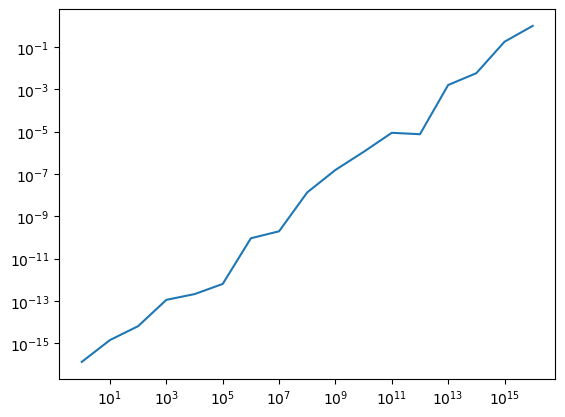

In [24]:
plt.loglog(x, err_relativo)

## Esercizio 2 
Si consideri l'equazione quadratica $x^2 + 2px - q = 0 $ con $p=10^5$ e $q=10^{-i}$, i=0,..,10

- Si stabilisca se il problema relativo al calcolo della soluzione $x= -p+\sqrt{p^2+q}$ risulta essere ben condizionato per tutti i valori di q assegnati;

- Si calcoli la soluzione x dell'equazione mediante la formula risolutiva indicata al punto precedente e si dica se l'algoritmo di calcolo risulta numericamente stabile  per i valori di q assegnati

- si individui una forma stabile per il calcolo della soluzione e si verifichi se l'algoritmo di calcolo risulta numericamente stabile per i valori di q assegnati.

In [34]:
p = 10.0**5
q = 10.0**(-np.arange(11))
n = q.shape[0]
f = lambda q: -p + np.sqrt(p**2 + q)
fp = lambda q: 0.5 / np.sqrt(p**2 + q)

ss = lambda q: q / (p + np.sqrt(p**2 + q))

K = np.abs(fp(q) * q / f(q))
soluzione = f(q)
sol_stabile = ss(q)


print(" \t q \t", "K(x) \t", "\t soluzione  ", "sol stabile ", "  Spacing")
for i in range(n):
    print("{:12.2e} {:12.2e} {:14.4e} {:14.4e} {:14.4e}".format(q[i], K[i], soluzione[i], sol_stabile[i],np.spacing(p**2)))

 	 q 	 K(x) 	 	 soluzione   sol stabile    Spacing
    1.00e+00     1.00e+00     5.0000e-06     5.0000e-06     1.9073e-06
    1.00e-01     1.00e+00     5.0000e-07     5.0000e-07     1.9073e-06
    1.00e-02     1.00e+00     5.0000e-08     5.0000e-08     1.9073e-06
    1.00e-03     1.00e+00     4.9913e-09     5.0000e-09     1.9073e-06
    1.00e-04     1.01e+00     4.9477e-10     5.0000e-10     1.9073e-06
    1.00e-05     1.15e+00     4.3656e-11     5.0000e-11     1.9073e-06
    1.00e-06     3.44e-01     1.4552e-11     5.0000e-12     1.9073e-06
    1.00e-07          inf     0.0000e+00     5.0000e-13     1.9073e-06
    1.00e-08          inf     0.0000e+00     5.0000e-14     1.9073e-06
    1.00e-09          inf     0.0000e+00     5.0000e-15     1.9073e-06
    1.00e-10          inf     0.0000e+00     5.0000e-16     1.9073e-06


/tmp/ipykernel_75282/2905073611.py:9: RuntimeWarning: divide by zero encountered in divide
  K = np.abs(fp(q) * q / f(q))


# Esercizio 3
Si consideri la serie armonica $S_N = \sum_{k=1}^{N} \frac{1}{k}$ calcolata in **singola precisione** (`float32`).

1. Calcolare $S_N$ con la **somma diretta** (da $k=1$ a $N$) e con la **somma inversa**
(da $k=N$ a $1$) in `float32`, per $N = 10^7$. Usare come riferimento la somma in
`float64`. Confrontare gli errori relativi.

2. Calcolare la somma diretta e inversa per $N = 10^3, 10^4, 10^5, 10^6, 10^7$
e visualizzare su grafico l'errore relativo al variare di $N$. Da quale $N$ la
somma diretta diventa significativamente meno accurata?

4. Ripetere il punto 1 in `float64` e verificare che in doppia precisione il fenomeno
non è osservabile per $N = 10^7$ (richiederebbe $N \sim 10^{15}$).



In [52]:
N = 1e+7
k = np.arange(1, N + 1, dtype=np.float32)
termini = np.float32(1.0) / k
sd = np.float32(0.0)
si = np.float32(0.0)

for t in termini:
    sd += t

for t in termini[::-1]:
    si = si + t

se = np.sum(1.0 / np.arange(1, N + 1))
print(se)

print(si, "errore relativo percentuale", (np.abs(si - se) / np.abs(se))*100)
print(sd, "errore relativo percentuale", (np.abs(sd - se) / np.abs(se))*100)

16.695311365859855
16.686031 errore relativo percentuale 0.05558461357059168
15.403683 errore relativo percentuale 7.736475402075245


# Esercizio 4

Si stabilisca se il problema relativo al calcolo della funzione $f(x)= \frac  {(1+x)-1 }  {x }$ per $x= 10^{-i }$ $  i=1,2,...,20$  risulta essere ben
condizionato per tutti i valori di x assegnati; verificare sperimentalmente la stabilità numerica dell'algoritmo di valutazione

## Esercizio 5 — Somma di una serie alternante: $\ln(2)$

Si sa che $\ln(2) = \sum_{k=1}^{\infty} \frac{(-1)^{k+1}}{k} = 1 - \frac{1}{2} + \frac{1}{3} - \cdots$

1. Calcolare la somma parziale troncata a $N = 1000$ termini con la somma **diretta** (da $k=1$ a $N$) e con la somma **inversa** (da $k=N$ a $1$). Confrontare l'errore relativo rispetto a `np.log(2)`. Quale dei due ordini di somma è più accurato e perché?

2. Calcolare la somma per $N = 10, 100, 1000, 10000$ termini e visualizzare su grafico l'errore relativo al variare di $N$ per entrambi gli ordini di somma.

3. Utilizzare la formula alternativa numericamente più favorevole:
$$\ln(2) = \sum_{k=0}^{\infty} \frac{1}{(2k+1)(2k+2)}$$
e confrontare la velocità di convergenza.

## Esercizio 6
Calcolare l'approssimazione della derivata prima di f(x) = sin(x) in x = 1
mediante l'algoritmo del rapporto incrementale (f(x + h) - f(x))/h per valori decrescenti
di h, confrontandolo con il valore fornito dalla funzione di libreria per f'(x)
mediante calcolo dell'errore relativo.